# Paramter Estimation for Recurrence Analysis

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from pose_dynamics.nonlinear.state_space_recon import (
    compute_ami_curve,
    compute_fnn_curve,
)

# Load the subset exported earlier
PREPROC_PATH = Path(
    "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed_subset.csv"
)

df = pd.read_csv(PREPROC_PATH)
print(f"Loaded subset data: {df.shape}")
df.head()


Loaded subset data: (455138, 25)


,time_s,pair_trial,pair_id,trial_id,party,Pair,Trial,Condition,Leader,Role,...,right_ankle_z,left_wrist_x,left_wrist_y,left_wrist_z,right_wrist_x,right_wrist_y,right_wrist_z,nose_x,nose_y,nose_z
0,0.000000,P001_T10,P001,T10,P1,1,10,uni,P2,Follower,...,-0.091969,-0.149713,-0.016407,0.009458,0.490658,0.097928,-0.008924,0.094641,0.665203,0.053315
1,0.033333,P001_T10,P001,T10,P1,1,10,uni,P2,Follower,...,-0.094887,-0.153912,-0.015823,0.009935,0.509625,0.110464,0.015013,0.098356,0.664395,0.051469
2,0.066667,P001_T10,P001,T10,P1,1,10,uni,P2,Follower,...,-0.096616,-0.157710,-0.015212,0.010135,0.525448,0.120701,0.035587,0.101730,0.663812,0.050101
3,0.100000,P001_T10,P001,T10,P1,1,10,uni,P2,Follower,...,-0.096223,-0.160823,-0.014334,0.009813,0.536303,0.126745,0.050855,0.104733,0.663594,0.049178
4,0.133333,P001_T10,P001,T10,P1,1,10,uni,P2,Follower,...,-0.093206,-0.163079,-0.012694,0.008838,0.541429,0.126892,0.060034,0.107832,0.663700,0.048247


In [2]:
KEYPOINTS_OF_INTEREST = [
    "left_ankle",
    "right_ankle",
    "left_wrist",
    "right_wrist",
    "nose",
]

# Group data by trial
trial_groups = dict(tuple(df.groupby("pair_trial")))
print(f"Found {len(trial_groups)} trials")

def compute_magnitude_xyz(df_trial: pd.DataFrame, base: str) -> np.ndarray:
    """Return magnitude of 3D keypoint position for one trial."""
    x = df_trial[f"{base}_x"].to_numpy()
    y = df_trial[f"{base}_y"].to_numpy()
    z = df_trial[f"{base}_z"].to_numpy()
    return np.sqrt(x**2 + y**2 + z**2)

# signals_per_kp: kp -> list of 1D arrays (one per trial)
signals_per_kp = {kp: [] for kp in KEYPOINTS_OF_INTEREST}

for trial_id, df_trial in trial_groups.items():
    for kp in KEYPOINTS_OF_INTEREST:
        sig = compute_magnitude_xyz(df_trial, kp)

        # optional: skip extremely short segments
        if len(sig) < 200:  # tweak threshold if needed
            continue

        signals_per_kp[kp].append(sig)

for kp, lst in signals_per_kp.items():
    print(f"{kp}: {len(lst)} usable trials")


Found 216 trials
left_ankle: 216 usable trials
right_ankle: 216 usable trials
left_wrist: 216 usable trials
right_wrist: 216 usable trials
nose: 216 usable trials


## Average Mutual Information (AMI) for Time Delay

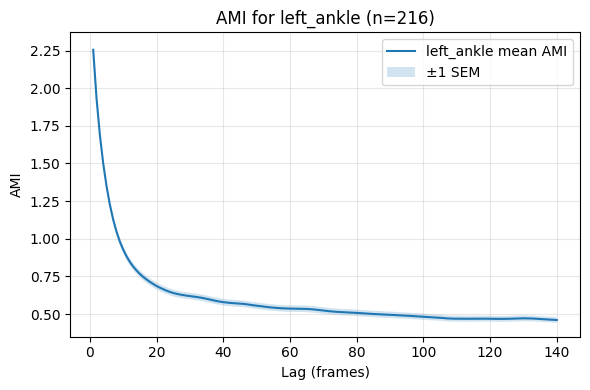

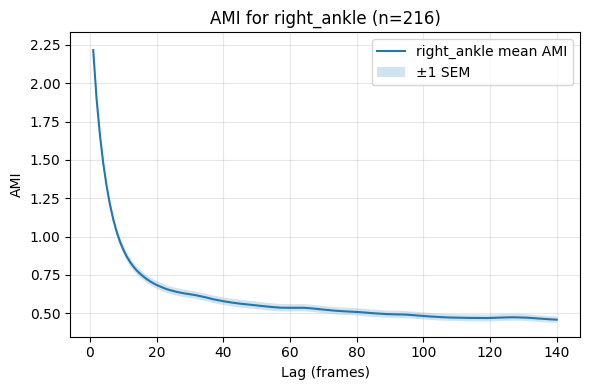

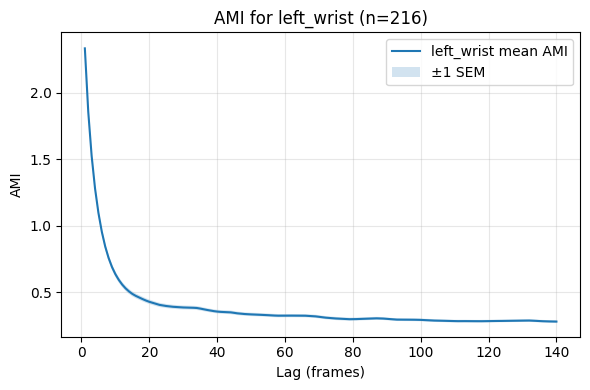

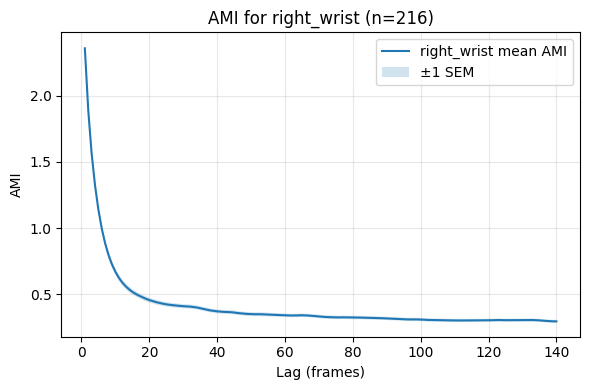

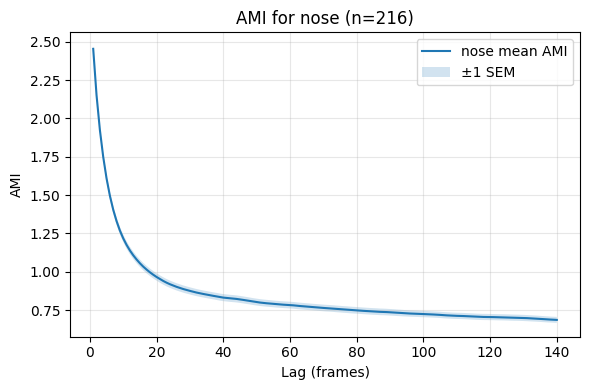

In [3]:
AMI_MIN_LAG = 1
AMI_MAX_LAG = 140

ami_summary = {}  # kp -> dict with lags, mean, std, n_trials

for kp, series_list in signals_per_kp.items():
    lags_ref = None
    all_ami = []

    for sig in series_list:
        res = compute_ami_curve(sig,
                                min_lag=AMI_MIN_LAG,
                                max_lag=AMI_MAX_LAG)
        if res is None:
            continue

        lags = res["lags"]
        vals = res["ami"]

        if lags_ref is None:
            lags_ref = lags
        else:
            if not np.array_equal(lags, lags_ref):
                # if this happens often we can align later; for now skip
                continue

        all_ami.append(vals)

    if not all_ami or lags_ref is None:
        print(f"No valid AMI results for {kp}")
        continue

    all_ami = np.vstack(all_ami)  # (n_trials, n_lags)
    mean_ami = np.nanmean(all_ami, axis=0)
    std_ami  = np.nanstd(all_ami, axis=0)
    n_trials = all_ami.shape[0]

    ami_summary[kp] = {
        "lags": lags_ref,
        "mean_ami": mean_ami,
        "std_ami": std_ami,
        "n_trials": n_trials,
    }

    # Plot mean ± SEM for this keypoint
    sem_ami = std_ami / np.sqrt(n_trials)

    plt.figure(figsize=(6, 4))
    plt.plot(lags_ref, mean_ami, label=f"{kp} mean AMI")
    plt.fill_between(lags_ref,
                     mean_ami - sem_ami,
                     mean_ami + sem_ami,
                     alpha=0.2,
                     label="±1 SEM")
    plt.xlabel("Lag (frames)")
    plt.ylabel("AMI")
    plt.title(f"AMI for {kp} (n={n_trials})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## False Nearest Neighbors (FNN) for Embedding Dimension

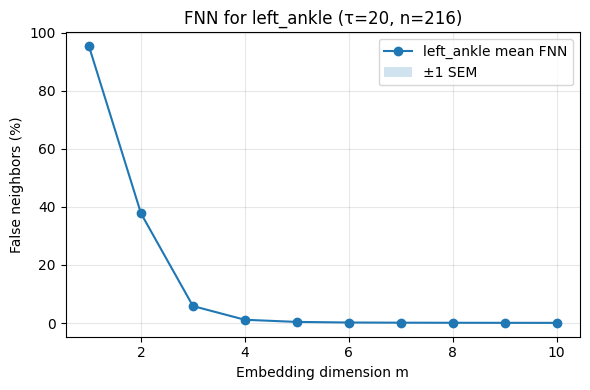

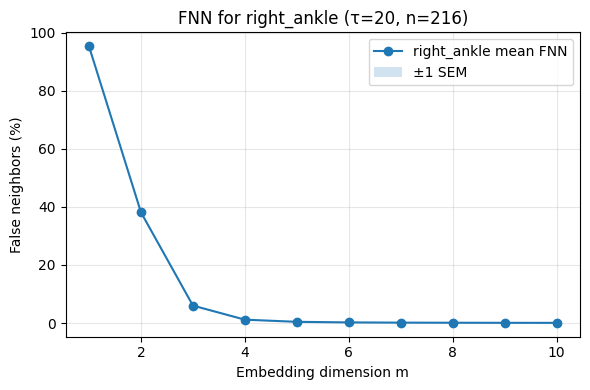

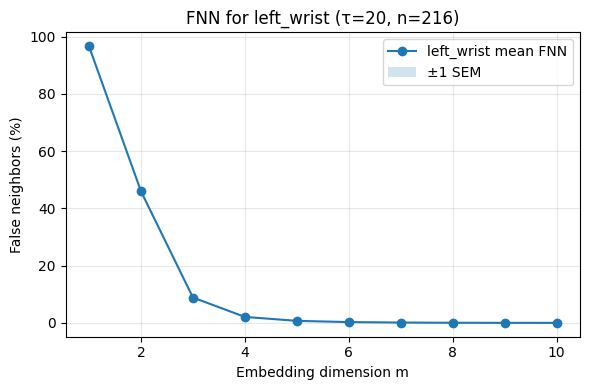

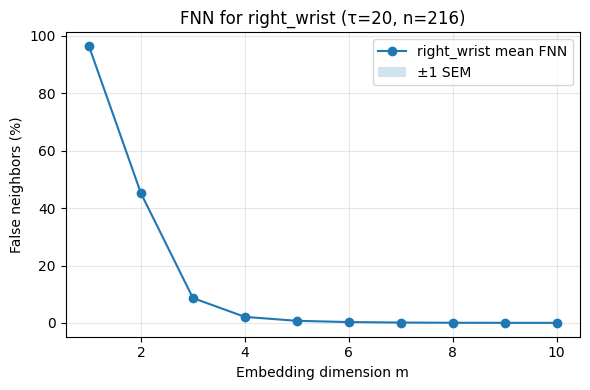

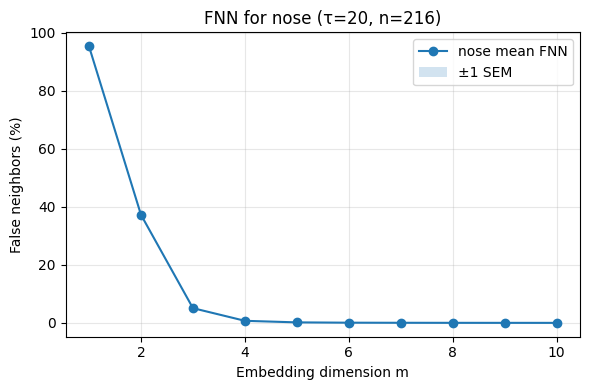

In [4]:
TAU = 20  # chosen based on AMI results
MIN_DIM = 1
MAX_DIM = 10

fnn_summary = {}  # kp -> dict with dims, mean, std, n_trials

for kp, series_list in signals_per_kp.items():
    dims_ref = None
    all_pct = []

    for sig in series_list:
        res = compute_fnn_curve(
            sig,
            tau=TAU,
            min_dim=MIN_DIM,
            max_dim=MAX_DIM,
        )
        if res is None:
            continue

        dims = res["dims"]
        pct  = res["pct_fnn"]

        if dims_ref is None:
            dims_ref = dims
        else:
            if not np.array_equal(dims, dims_ref):
                continue

        all_pct.append(pct)

    if not all_pct or dims_ref is None:
        print(f"No valid FNN results for {kp}")
        continue

    all_pct = np.vstack(all_pct)  # (n_trials, n_dims)
    mean_pct = np.nanmean(all_pct, axis=0)
    std_pct  = np.nanstd(all_pct, axis=0)
    n_trials = all_pct.shape[0]

    fnn_summary[kp] = {
        "dims": dims_ref,
        "mean_pct": mean_pct,
        "std_pct": std_pct,
        "n_trials": n_trials,
    }

    # Plot mean ± SEM for this keypoint
    sem_pct = std_pct / np.sqrt(n_trials)

    plt.figure(figsize=(6, 4))
    plt.plot(dims_ref, mean_pct, marker="o", label=f"{kp} mean FNN")
    plt.fill_between(dims_ref,
                     mean_pct - sem_pct,
                     mean_pct + sem_pct,
                     alpha=0.2,
                     label="±1 SEM")
    plt.xlabel("Embedding dimension m")
    plt.ylabel("False neighbors (%)")
    plt.title(f"FNN for {kp} (τ={TAU}, n={n_trials})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()